# Notebook 4: SQL Analysis:Business Queries Against SQLite Database
**Project:** Ontario Insurance Claims Intelligence Platform  
**Goal:** Demonstrate SQL proficiency: load scored claims into a relational database
and run analytical queries using CTEs, window functions, and JOINs.

In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sqlalchemy import create_engine, text

def find_project_root():
    candidates = []
    vsc_path = globals().get('__vsc_ipynb_file__')
    if vsc_path:
        candidates.append(Path(vsc_path).parent)
    candidates.append(Path.cwd())
    for start in candidates:
        for folder in [start] + list(start.parents):
            if (folder / 'requirements.txt').exists():
                return folder
    raise FileNotFoundError("Cannot find project root")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

PROCESSED    = PROJECT_ROOT / 'data' / 'processed' / 'insurance_claims_clean.csv'
QUEUE        = PROJECT_ROOT / 'outputs' / 'reports' / 'final_priority_queue.csv'
DB_PATH      = PROJECT_ROOT / 'data' / 'processed' / 'insurance_claims.db'
FIGURES      = PROJECT_ROOT / 'outputs' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

print("Paths set. Loading data...")
df_clean = pd.read_csv(PROCESSED)
df_queue = pd.read_csv(QUEUE)
print(f"Clean data: {df_clean.shape}")
print(f"Scored queue: {df_queue.shape}")

Paths set. Loading data...
Clean data: (1000, 45)
Scored queue: (1000, 15)


## Step 1: Build the SQLite Database

In [2]:
engine = create_engine(f'sqlite:///{DB_PATH}')

# --- fact_claims ---
fact_cols = [
    'policy_number','total_claim_amount','injury_claim','property_claim',
    'vehicle_claim','incident_date','incident_type','incident_severity',
    'incident_state','incident_city','incident_hour_of_the_day',
    'number_of_vehicles_involved','bodily_injuries','witnesses',
    'property_damage','police_report_available','authorities_contacted',
    'fraud_reported'
]
fact = df_clean[fact_cols].copy()
fact.columns = [c.replace('incident_hour_of_the_day','incident_hour')
                 .replace('number_of_vehicles_involved','number_of_vehicles')
                 .replace('police_report_available','police_report')
                 for c in fact.columns]

# Add ML scores from the queue
scores = df_queue[['policy_number','anomaly_score','fraud_probability','region']].copy()
fact = fact.merge(scores, on='policy_number', how='left')
fact.to_sql('fact_claims', engine, if_exists='replace', index=False)

# --- dim_policies ---
policy_cols = [
    'policy_number','policy_bind_date','policy_state','policy_csl',
    'policy_deductable','policy_annual_premium','umbrella_limit',
    'insured_zip','insured_sex','insured_education_level',
    'insured_occupation','insured_relationship','months_as_customer','age',
    'capital-gains','capital-loss'
]
dim_p = df_clean[policy_cols].copy()
dim_p.columns = [c.replace('policy_deductable','policy_deductible')
                  .replace('insured_education_level','insured_education')
                  .replace('capital-gains','capital_gains')
                  .replace('capital-loss','capital_loss')
                  for c in dim_p.columns]
dim_p.to_sql('dim_policies', engine, if_exists='replace', index=False)

# --- dim_vehicles ---
dim_v = df_clean[['policy_number','auto_make','auto_model','auto_year','vehicle_age']].copy()
dim_v.to_sql('dim_vehicles', engine, if_exists='replace', index=False)

print("Database built successfully.")
with engine.connect() as conn:
    for table in ['fact_claims','dim_policies','dim_vehicles']:
        count = conn.execute(text(f"SELECT COUNT(*) FROM {table}")).scalar()
        print(f"  {table}: {count:,} rows")

Database built successfully.
  fact_claims: 1,000 rows
  dim_policies: 1,000 rows
  dim_vehicles: 1,000 rows


## Step 2: Run Query 1 : Loss Ratio by Region

In [3]:
query_loss_ratio = """
WITH regional_summary AS (
    SELECT
        c.region,
        COUNT(*)                                         AS total_claims,
        ROUND(SUM(p.policy_annual_premium), 2)           AS total_premiums,
        ROUND(SUM(c.total_claim_amount), 2)              AS total_claims_paid,
        ROUND(AVG(c.total_claim_amount), 2)              AS avg_claim_amount,
        ROUND(AVG(p.policy_annual_premium), 2)           AS avg_premium,
        SUM(c.fraud_reported)                            AS fraud_count,
        ROUND(AVG(c.fraud_reported) * 100, 1)            AS fraud_rate_pct
    FROM fact_claims c
    JOIN dim_policies p ON c.policy_number = p.policy_number
    GROUP BY c.region
),
with_loss_ratio AS (
    SELECT *,
        ROUND(CAST(total_claims_paid AS REAL) / NULLIF(total_premiums, 0), 2) AS loss_ratio
    FROM regional_summary
)
SELECT
    region, total_claims, avg_premium, avg_claim_amount,
    loss_ratio, fraud_rate_pct,
    CASE WHEN loss_ratio > (SELECT AVG(loss_ratio) FROM with_loss_ratio)
         THEN 'HIGH RISK' ELSE 'Normal' END AS risk_flag
FROM with_loss_ratio
ORDER BY loss_ratio DESC;
"""

df_lr = pd.read_sql(query_loss_ratio, engine)
print("LOSS RATIO BY REGION (via SQL)")
print("=" * 60)
print(df_lr.to_string(index=False))

LOSS RATIO BY REGION (via SQL)
           region  total_claims  avg_premium  avg_claim_amount  loss_ratio  fraud_rate_pct risk_flag
      Ohio Valley           187      1255.38          53940.70       42.97            25.7 HIGH RISK
     Indiana Belt           233      1261.43          54046.22       42.85            25.3 HIGH RISK
   Michigan South            72      1228.46          52064.58       42.38            40.3 HIGH RISK
Great Lakes North           214      1245.29          52674.72       42.30            17.8 HIGH RISK
    Upper Midwest           294      1268.01          51228.64       40.40            24.8    Normal


## Step 3: Run Query 2 : Fraud Pattern Analysis (Window Functions)

In [4]:
query_patterns = """
WITH incident_fraud_rates AS (
    SELECT
        incident_type,
        incident_severity,
        COUNT(*)                                AS claim_count,
        SUM(fraud_reported)                     AS fraud_count,
        ROUND(AVG(fraud_reported) * 100, 1)    AS fraud_rate_pct,
        ROUND(AVG(total_claim_amount), 0)       AS avg_claim,
        ROUND(AVG(bodily_injuries), 2)          AS avg_injuries,
        ROUND(AVG(witnesses), 2)                AS avg_witnesses
    FROM fact_claims
    GROUP BY incident_type, incident_severity
),
with_avg AS (
    SELECT *,
        ROUND(AVG(fraud_rate_pct) OVER (), 1)  AS portfolio_avg,
        fraud_rate_pct - AVG(fraud_rate_pct) OVER () AS vs_avg
    FROM incident_fraud_rates
)
SELECT
    incident_type, incident_severity, claim_count,
    fraud_rate_pct, portfolio_avg,
    ROUND(vs_avg, 1) AS pct_pts_above_avg,
    avg_claim, avg_injuries, avg_witnesses
FROM with_avg
ORDER BY vs_avg DESC;
"""

df_patterns = pd.read_sql(query_patterns, engine)
print("FRAUD RATE BY INCIDENT TYPE + SEVERITY (window functions)")
print("=" * 65)
print(df_patterns.to_string(index=False))

FRAUD RATE BY INCIDENT TYPE + SEVERITY (window functions)
           incident_type incident_severity  claim_count  fraud_rate_pct  portfolio_avg  pct_pts_above_avg  avg_claim  avg_injuries  avg_witnesses
Single Vehicle Collision      Major Damage          132            62.9           20.4               42.5    65966.0          1.02           1.59
 Multi-vehicle Collision      Major Damage          144            58.3           20.4               37.9    62327.0          1.03           1.55
 Multi-vehicle Collision        Total Loss          145            13.1           20.4               -7.3    61014.0          1.00           1.59
Single Vehicle Collision        Total Loss          135            12.6           20.4               -7.8    63228.0          0.92           1.37
Single Vehicle Collision      Minor Damage          136            12.5           20.4               -7.9    64179.0          0.97           1.49
              Parked Car      Minor Damage           42           

## Step 4: Run Query 3 : Policy Vintage Risk (RANK window function)

In [5]:
query_vintage = """
WITH policy_age_cohorts AS (
    SELECT
        c.policy_number,
        c.fraud_reported,
        c.total_claim_amount,
        p.policy_annual_premium,
        CASE
            WHEN CAST(p.months_as_customer AS INTEGER) < 12  THEN '0-1 year'
            WHEN CAST(p.months_as_customer AS INTEGER) < 36  THEN '1-3 years'
            WHEN CAST(p.months_as_customer AS INTEGER) < 60  THEN '3-5 years'
            WHEN CAST(p.months_as_customer AS INTEGER) < 120 THEN '5-10 years'
            ELSE '10+ years'
        END AS customer_tenure
    FROM fact_claims c
    JOIN dim_policies p ON c.policy_number = p.policy_number
),
cohort_summary AS (
    SELECT
        customer_tenure,
        COUNT(*)                                AS policies,
        ROUND(AVG(fraud_reported) * 100, 1)    AS fraud_rate_pct,
        ROUND(AVG(total_claim_amount), 0)       AS avg_claim,
        ROUND(AVG(policy_annual_premium), 0)    AS avg_premium
    FROM policy_age_cohorts
    GROUP BY customer_tenure
)
SELECT
    customer_tenure, policies, fraud_rate_pct,
    avg_claim, avg_premium,
    RANK() OVER (ORDER BY fraud_rate_pct DESC) AS fraud_risk_rank
FROM cohort_summary
ORDER BY fraud_risk_rank;
"""

df_vintage = pd.read_sql(query_vintage, engine)
print("POLICY VINTAGE RISK — Does customer tenure predict fraud?")
print("=" * 60)
print(df_vintage.to_string(index=False))

POLICY VINTAGE RISK — Does customer tenure predict fraud?
customer_tenure  policies  fraud_rate_pct  avg_claim  avg_premium  fraud_risk_rank
       0-1 year        24            29.2    51992.0       1182.0                1
      1-3 years        42            26.2    51811.0       1291.0                2
     5-10 years       158            25.9    50968.0       1224.0                3
      10+ years       741            24.4    53242.0       1262.0                4
      3-5 years        35            20.0    52375.0       1296.0                5


## Step 5: Visualise the SQL Query Results

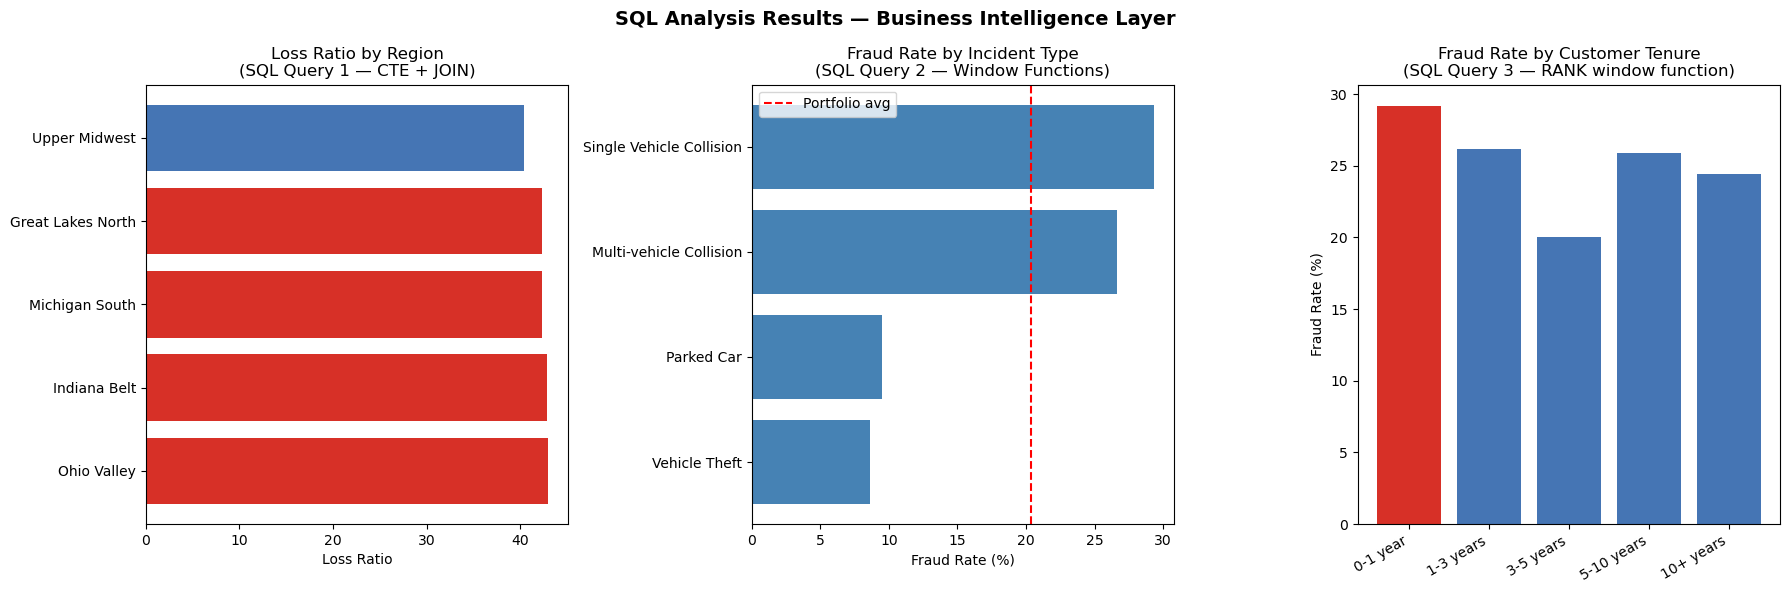

SQL analysis chart saved.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('SQL Analysis Results — Business Intelligence Layer',
             fontsize=14, fontweight='bold')

# Chart 1: Loss ratio by region from SQL
colors = ['#d73027' if r == 'HIGH RISK' else '#4575b4' for r in df_lr['risk_flag']]
axes[0].barh(df_lr['region'], df_lr['loss_ratio'], color=colors)
axes[0].set_title('Loss Ratio by Region\n(SQL Query 1 — CTE + JOIN)')
axes[0].set_xlabel('Loss Ratio')

# Chart 2: Fraud rate by incident type from SQL
top_patterns = df_patterns.groupby('incident_type')['fraud_rate_pct'].mean().sort_values()
axes[1].barh(top_patterns.index, top_patterns.values, color='steelblue')
axes[1].axvline(df_patterns['portfolio_avg'].iloc[0], color='red',
                linestyle='--', label='Portfolio avg')
axes[1].set_title('Fraud Rate by Incident Type\n(SQL Query 2 — Window Functions)')
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].legend()

# Chart 3: Fraud rate by customer tenure from SQL
tenure_order = ['0-1 year','1-3 years','3-5 years','5-10 years','10+ years']
df_v = df_vintage.set_index('customer_tenure').reindex(tenure_order)
colors_v = ['#d73027' if r == 1 else '#4575b4' for r in df_vintage.set_index('customer_tenure').reindex(tenure_order)['fraud_risk_rank']]
axes[2].bar(range(len(df_v)), df_v['fraud_rate_pct'], color=colors_v)
axes[2].set_xticks(range(len(df_v)))
axes[2].set_xticklabels(tenure_order, rotation=30, ha='right')
axes[2].set_title('Fraud Rate by Customer Tenure\n(SQL Query 3 — RANK window function)')
axes[2].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.savefig(FIGURES / '04_sql_analysis_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("SQL analysis chart saved.")

## Summary : SQL Skills Demonstrated

| SQL Concept | Where Used |
|-------------|-----------|
| CREATE TABLE / INSERT | Schema design + data loading |
| JOIN (fact + dimension tables) | Every query — star schema pattern |
| GROUP BY + aggregations | Regional summaries, pattern analysis |
| CTE (WITH clause) | All 3 queries use multi-step CTEs |
| Window functions (AVG OVER, RANK OVER) | Fraud rate vs portfolio avg, tenure ranking |
| CASE WHEN | Risk flagging, tenure bucketing |
| NULLIF | Safe division for loss ratio |